In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/МАИ Фреймворки Python для анализа данных/Лекция 4/data.csv", sep=",")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
df.drop(columns=['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], inplace=True)
df = df.rename(columns={"Engine HP": "HP",
                        "Engine Cylinders": "Cylinders",
                        "Transmission Type": "Transmission",
                        "Driven_Wheels": "Drive Mode",
                        "highway MPG": "MPG-H",
                        "city mpg": "MPG-C",
                        "MSRP": "Price" })
df = df.drop_duplicates()
df['HP'] = df['HP'].fillna(df['HP'].median())
df.drop(columns=['Cylinders'], inplace=True)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    col_data = df[col].dropna()
    if len(col_data) > 0:
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Фильтруем строки датафрейма, а не присваиваем колонке
        mask = ~((df[col] < lower_bound) | (df[col] > upper_bound))
        df = df[mask]

# Сброс индекса после фильтрации строк (хорошая практика)
df.reset_index(drop=True, inplace=True)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded_data = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index # Сохраняем тот же индекс
)
# Удаляем оригинальные категориальные колонки из основного df
df = df.drop(columns=cat_cols)
# Объединяем исходный df с закодированными данными
df = pd.concat([df, ohe_df], axis=1)
# Проверка результата
print(df.head())

   Year     HP  MPG-H  MPG-C  Price  Make_Acura  Make_Alfa Romeo  Make_Audi  \
0  2011  335.0     26     19  46135         0.0              0.0        0.0   
1  2011  300.0     28     19  40650         0.0              0.0        0.0   
2  2011  300.0     28     20  36350         0.0              0.0        0.0   
3  2011  230.0     28     18  29450         0.0              0.0        0.0   
4  2011  230.0     28     18  34500         0.0              0.0        0.0   

   Make_BMW  Make_Buick  ...  Model_xB  Model_xD  \
0       1.0         0.0  ...       0.0       0.0   
1       1.0         0.0  ...       0.0       0.0   
2       1.0         0.0  ...       0.0       0.0   
3       1.0         0.0  ...       0.0       0.0   
4       1.0         0.0  ...       0.0       0.0   

   Transmission_AUTOMATED_MANUAL  Transmission_AUTOMATIC  Transmission_MANUAL  \
0                            0.0                     0.0                  1.0   
1                            0.0                  


📊 Метрики для Train:
  MAE:  2,413.05
  RMSE: 3,395.23
  R²:   0.9461
  MAPE: 14.81%

📊 Метрики для Test:
  MAE:  2,780.77
  RMSE: 4,040.58
  R²:   0.9234
  MAPE: 19.24%


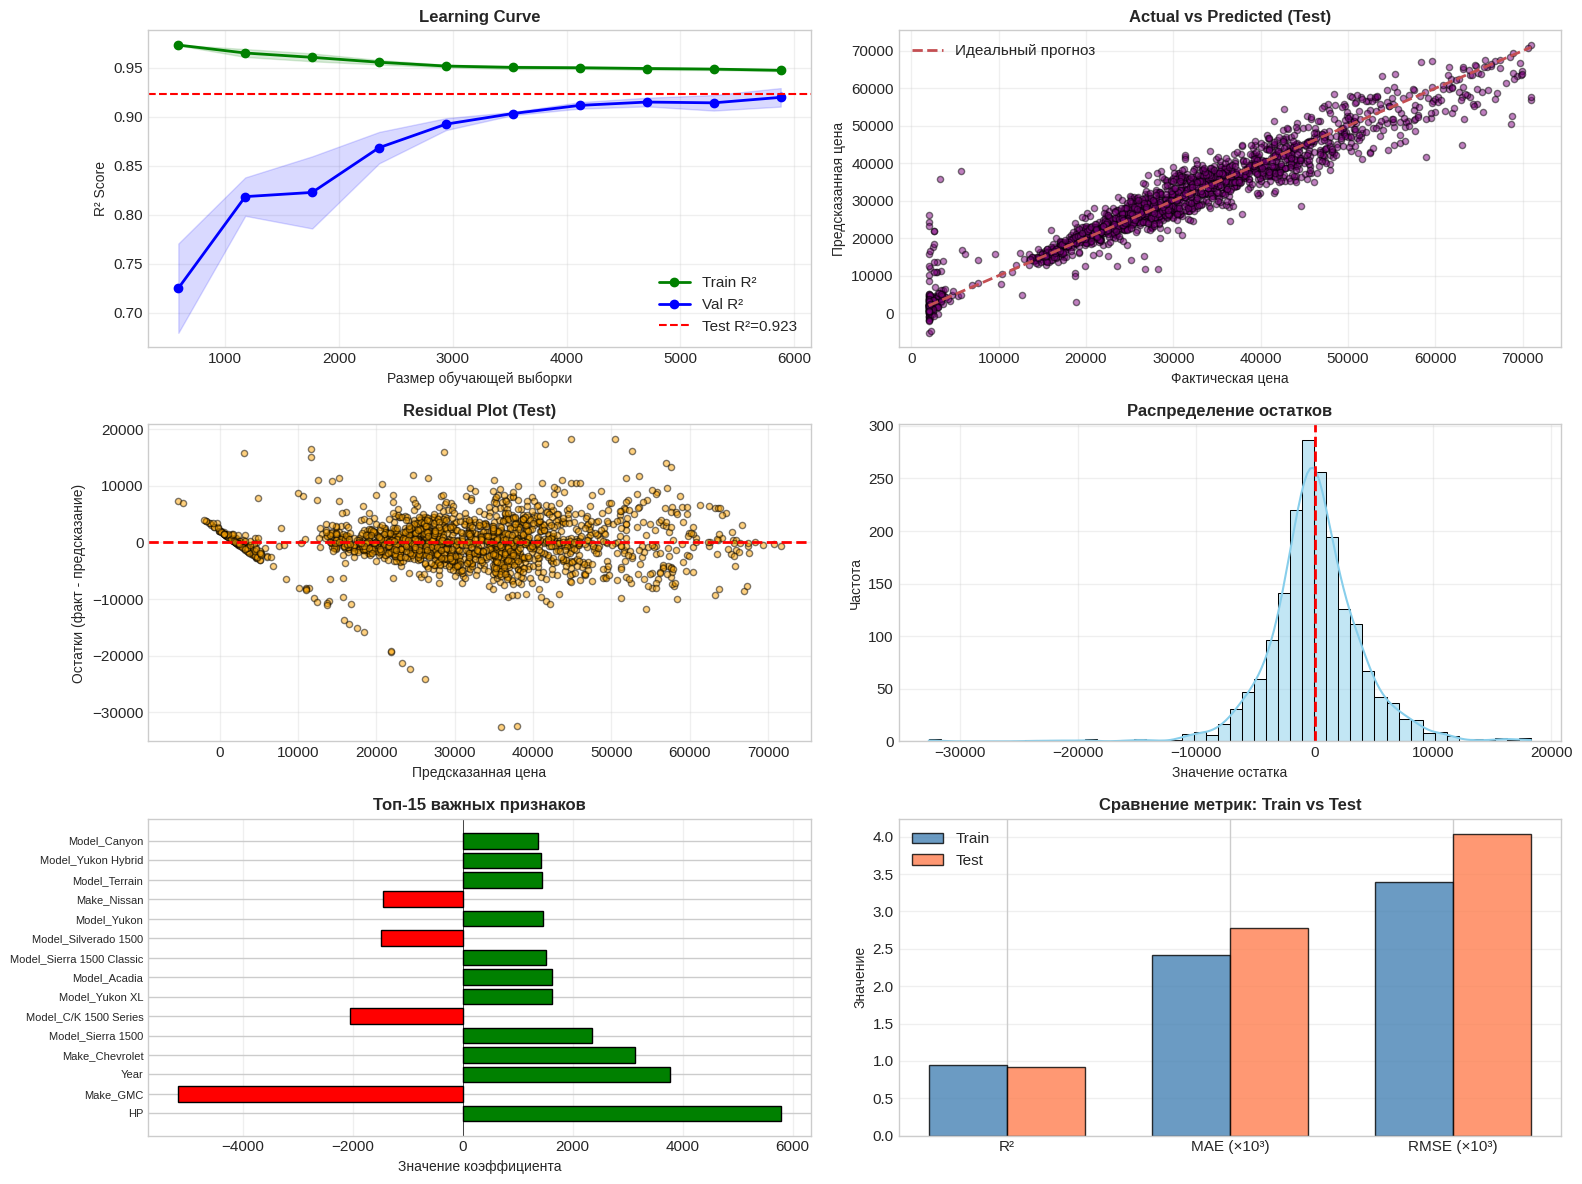


🔍 Диагностика:
  Разница R² (Train - Test): 0.0227
  ✅ Модель обобщает данные адекватно.

📈 Топ-10 факторов, УВЕЛИЧИВАЮЩИХ цену:
  + HP: 5783.38
  + Year: 3773.85
  + Make_Chevrolet: 3138.66
  + Model_Sierra 1500: 2360.17
  + Model_Yukon XL: 1624.37
  + Model_Acadia: 1622.91
  + Model_Sierra 1500 Classic: 1511.94
  + Model_Yukon: 1468.68
  + Model_Terrain: 1444.12
  + Model_Yukon Hybrid: 1425.97

📉 Топ-10 факторов, УМЕНЬШАЮЩИХ цену:
  - Make_GMC: -5167.72
  - Model_C/K 1500 Series: -2049.35
  - Model_Silverado 1500: -1482.66
  - Make_Nissan: -1454.54


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. Подготовка данных
# ============================================

# Целевая переменная
y = df['Price']
X = df.drop(columns=['Price'])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Масштабирование признаков (важно для интерпретации коэффициентов)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 2. Обучение модели
# ============================================

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================
# 3. Оценка качества модели
# ============================================

def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Оценка на обеих выборках
train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# ============================================
# 4. Визуализация результатов (2 графика в ряд)
# ============================================

from sklearn.model_selection import learning_curve

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# --- 4.1 Learning Curve (Кривая обучения) ---
ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R²={test_metrics["R2"]:.3f}')
ax1.legend()

# --- 4.2 Actual vs Predicted ---
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическая цена', fontsize=10)
ax2.set_ylabel('Предсказанная цена', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- 4.3 Остатки (Residuals) ---
ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанная цена', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# --- 4.4 Распределение остатков ---
ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# --- 4.5 Коэффициенты модели (Топ-15 по модулю) ---
ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

# --- 4.6 Сравнение метрик Train/Test ---
ax6 = plt.subplot(3, 2, 6)
metrics_names = ['R²', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['R²', 'MAE (×10³)', 'RMSE (×10³)'])
ax6.set_ylabel('Значение', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. Дополнительная диагностика
# ============================================

# Проверка на переобучение
r2_diff = train_metrics['R2'] - test_metrics['R2']
print(f"\n🔍 Диагностика:")
print(f"  Разница R² (Train - Test): {r2_diff:.4f}")
if r2_diff > 0.1:
    print("  ⚠️  Возможное переобучение! Рассмотрите регуляризацию (Ridge/Lasso).")
elif r2_diff < -0.1:
    print("  ⚠️  Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("  ✅ Модель обобщает данные адекватно.")

# Топ-10 положительных и отрицательных факторов влияния на цену
print(f"\n📈 Топ-10 факторов, УВЕЛИЧИВАЮЩИХ цену:")
top_positive = coefficients[coefficients['coef'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['coef']:.2f}")

print(f"\n📉 Топ-10 факторов, УМЕНЬШАЮЩИХ цену:")
top_negative = coefficients[coefficients['coef'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['coef']:.2f}")

# Классификация

## Логистическая регрессия

🚀 Запуск обучения Логистической Регрессии...

📊 Метрики для Train:
  Accuracy:  0.9297
  Precision: 0.9300
  Recall:    0.9293
  F1-Score:  0.9297

📊 Метрики для Test:
  Accuracy:  0.9250
  Precision: 0.9277
  Recall:    0.9217
  F1-Score:  0.9247
  AUC-ROC:   0.9798


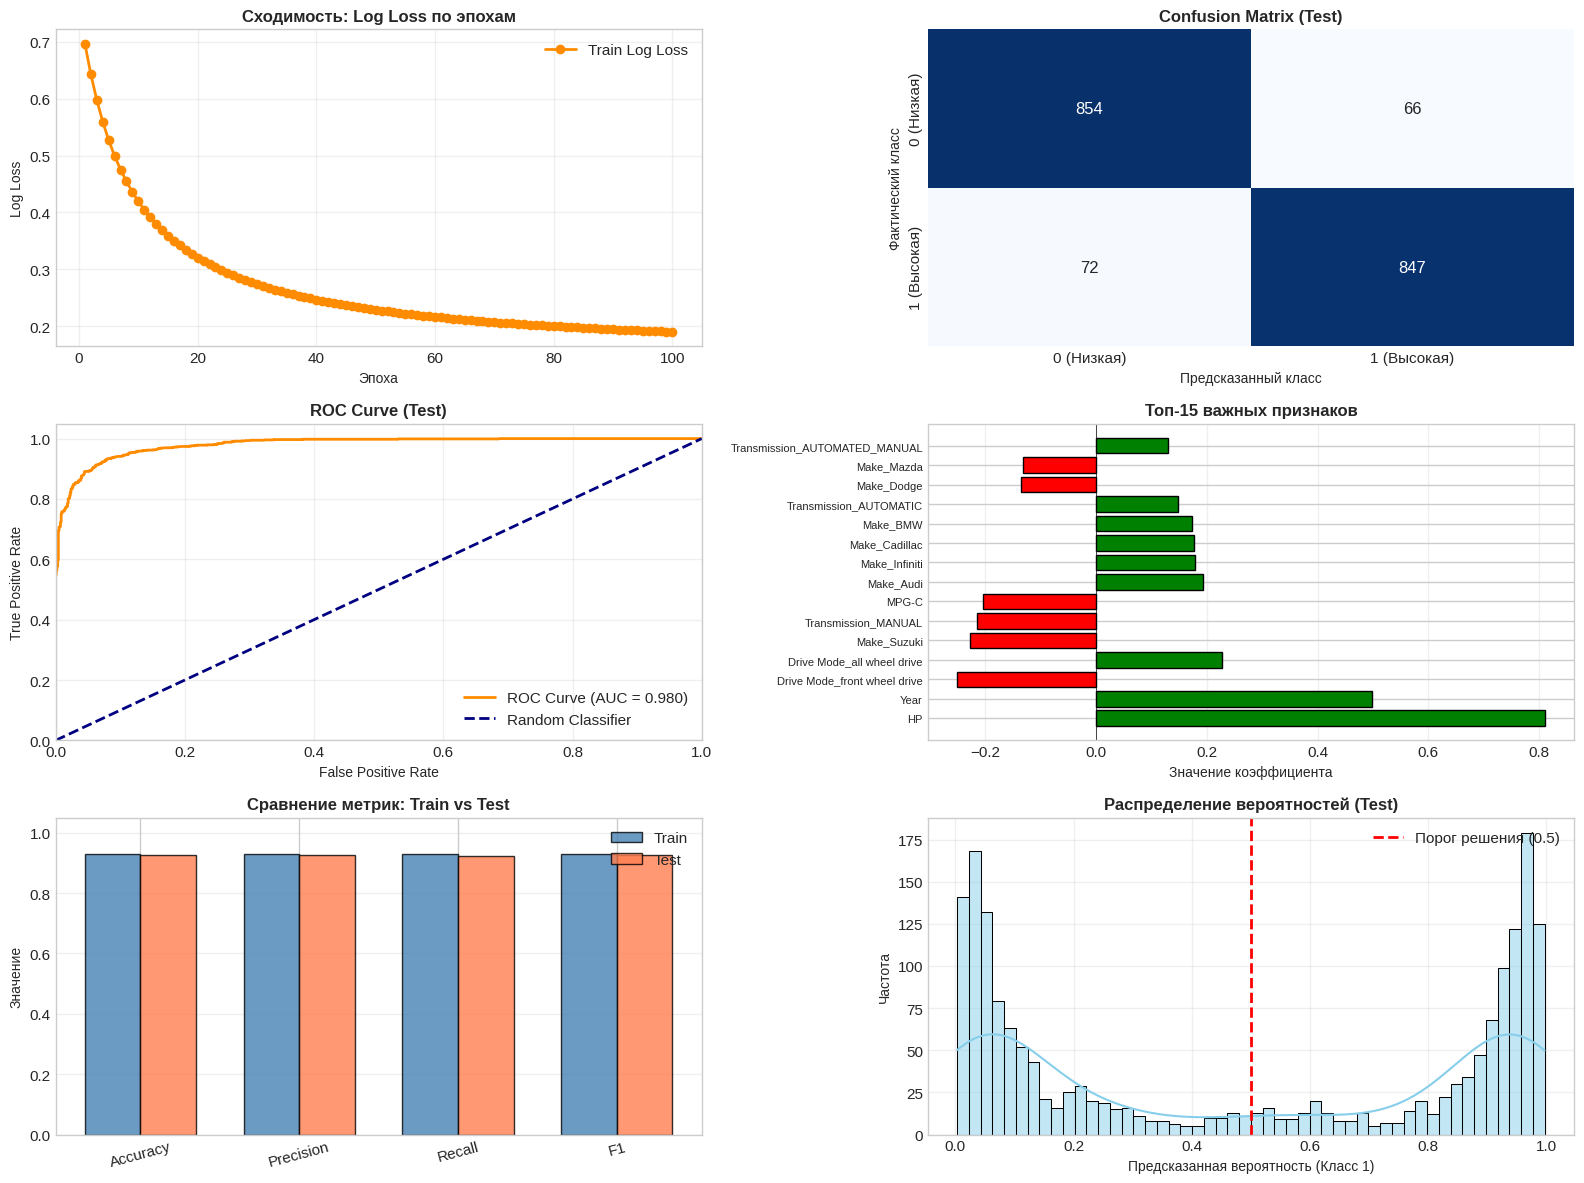


🔍 Диагностика Логистической Регрессии:
  Количество эпох: 100
  Learning Rate: 0.1
  Регуляризация: l2 (alpha=0.01)
  Initial Loss: 0.6964
  Final Loss: 0.1903

✅ Хорошая сходимость: Loss снизился на 72.7%

✅ Модель обобщает данные адекватно.

📈 Топ-10 признаков, УВЕЛИЧИВАЮЩИХ вероятность высокой цены:
  + HP: 0.8099
  + Year: 0.4978
  + Drive Mode_all wheel drive: 0.2271
  + Make_Audi: 0.1928
  + Make_Infiniti: 0.1781
  + Make_Cadillac: 0.1778
  + Make_BMW: 0.1730
  + Transmission_AUTOMATIC: 0.1486
  + Transmission_AUTOMATED_MANUAL: 0.1305

📉 Топ-10 признаков, УМЕНЬШАЮЩИХ вероятность высокой цены:
  - Drive Mode_front wheel drive: -0.2504
  - Make_Suzuki: -0.2270
  - Transmission_MANUAL: -0.2153
  - MPG-C: -0.2036
  - Make_Dodge: -0.1356
  - Make_Mazda: -0.1315

🎯 Анализ оптимального порога классификации:
  Порог 0.3: Accuracy=0.913, F1=0.917
  Порог 0.4: Accuracy=0.920, F1=0.921
  Порог 0.5: Accuracy=0.925, F1=0.925
  Порог 0.6: Accuracy=0.918, F1=0.915
  Порог 0.7: Accuracy=0.904, 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. Класс Логистической Регрессии (С нуля)
# ============================================

class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty  # 'l2' или None
        self.alpha = alpha      # Коэффициент регуляризации
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        # Clip для предотвращения переполнения
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15  # Для предотвращения log(0)
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)

        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        # Добавляем L2 регуляризацию к лоссу
        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)

        return loss

    def fit(self, X, y):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # 1. Прямой проход (Forward Pass)
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            # 2. Вычисление ошибки (Log Loss)
            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            # 3. Обратный проход (Backward Pass) - вычисление градиентов
            error = y_pred_proba - y  # Производная Cross-Entropy + Sigmoid

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Добавляем градиент регуляризации
            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            # 4. Обновление весов
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        """Вероятность принадлежности к классу 1"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def score(self, X, y):
        """Точность модели"""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)

# ============================================
# 2. Подготовка данных
# ============================================

# !!! ВНИМАНИЕ: Логистическая регрессия решает задачу КЛАССИФИКАЦИИ !!!
# Преобразуем целевую переменную Price в бинарный класс

median_price = df['Price'].median()
y = (df['Price'] > median_price).astype(int)  # 1 если цена выше медианы, 0 иначе

X = df.drop(columns=['Price'])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# Масштабирование признаков (критично для градиентного спуска)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 3. Обучение модели
# ============================================

# Параметры обучения
n_epochs = 100
learning_rate = 0.1  # Можно подобрать (0.0001 - 0.5)

print("🚀 Запуск обучения Логистической Регрессии...")
model = LogisticRegressionCustom(
    learning_rate=learning_rate,
    n_iterations=n_epochs,
    random_state=42,
    penalty='l2',  # L2 регуляризация для предотвращения переобучения
    alpha=0.01
)
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# ============================================
# 4. Оценка качества модели
# ============================================

def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

# Оценка на обеих выборках
train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name="Train")
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba, dataset_name="Test")

# ============================================
# 5. Визуализация результатов
# ============================================

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# --- 5.1 Loss History (Log Loss по эпохам) ---
ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, n_epochs + 1), model.loss_history, 'o-', color='darkorange', linewidth=2, label='Train Log Loss')
ax1.set_xlabel('Эпоха', fontsize=10)
ax1.set_ylabel('Log Loss', fontsize=10)
ax1.set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- 5.2 Confusion Matrix (Test) ---
ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['0 (Низкая)', '1 (Высокая)'])
ax2.set_yticklabels(['0 (Низкая)', '1 (Высокая)'])

# --- 5.3 ROC Curve ---
ax3 = plt.subplot(3, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# --- 5.4 Распределение весов модели (Топ-15) ---
ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.weights
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_xlabel('Значение коэффициента', fontsize=10)
ax4.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.axvline(x=0, color='black', lw=0.5)
plt.setp(ax4.get_yticklabels(), fontsize=8)

# --- 5.5 Сравнение метрик Train/Test ---
ax5 = plt.subplot(3, 2, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names, rotation=15)
ax5.set_ylabel('Значение', fontsize=10)
ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# --- 5.6 Распределение предсказанных вероятностей ---
ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог решения (0.5)')
ax6.set_xlabel('Предсказанная вероятность (Класс 1)', fontsize=10)
ax6.set_ylabel('Частота', fontsize=10)
ax6.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. Дополнительная диагностика
# ============================================

print(f"\n🔍 Диагностика Логистической Регрессии:")
print(f"  Количество эпох: {n_epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Регуляризация: {model.penalty} (alpha={model.alpha})")
print(f"  Initial Loss: {model.loss_history[0]:.4f}")
print(f"  Final Loss: {model.loss_history[-1]:.4f}")

# Проверка сходимости
loss_reduction = (model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0] * 100
if loss_reduction > 50:
    print(f"\n✅ Хорошая сходимость: Loss снизился на {loss_reduction:.1f}%")
elif loss_reduction > 10:
    print(f"\n⚠️  Умеренная сходимость: Loss снизился на {loss_reduction:.1f}%")
else:
    print(f"\n⚠️  Плохая сходимость: Loss снизился только на {loss_reduction:.1f}%")
    print("   Попробуйте увеличить learning_rate или количество эпох")

# Проверка на переобучение
acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
if acc_diff > 0.1:
    print("\n⚠️  Возможное переобучение! Разница Accuracy > 10%")
    print("   Попробуйте увеличить alpha (регуляризацию)")
elif acc_diff < -0.05:
    print("\n⚠️  Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("\n✅ Модель обобщает данные адекватно.")

# Топ-10 положительных и отрицательных коэффициентов
print(f"\n📈 Топ-10 признаков, УВЕЛИЧИВАЮЩИХ вероятность высокой цены:")
top_positive = weights_df[weights_df['weight'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['weight']:.4f}")

print(f"\n📉 Топ-10 признаков, УМЕНЬШАЮЩИХ вероятность высокой цены:")
top_negative = weights_df[weights_df['weight'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['weight']:.4f}")

# ============================================
# 7. Анализ порогового значения (Threshold)
# ============================================

print("\n🎯 Анализ оптимального порога классификации:")
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds_to_check:
    y_pred_custom = (y_test_proba >= thresh).astype(int)
    f1_curr = f1_score(y_test, y_pred_custom)
    acc_curr = accuracy_score(y_test, y_pred_custom)
    print(f"  Порог {thresh}: Accuracy={acc_curr:.3f}, F1={f1_curr:.3f}")

    if f1_curr > best_f1:
        best_f1 = f1_curr
        best_threshold = thresh

print(f"\n✅ Оптимальный порог: {best_threshold} (F1={best_f1:.3f})")

## Прецептрон

🚀 Запуск обучения Перцептрона...

📊 Метрики для Train:
  Accuracy:  0.9023
  Precision: 0.9041
  Recall:    0.9002
  F1-Score:  0.9021

📊 Метрики для Test:
  Accuracy:  0.8874
  Precision: 0.8878
  Recall:    0.8868
  F1-Score:  0.8873


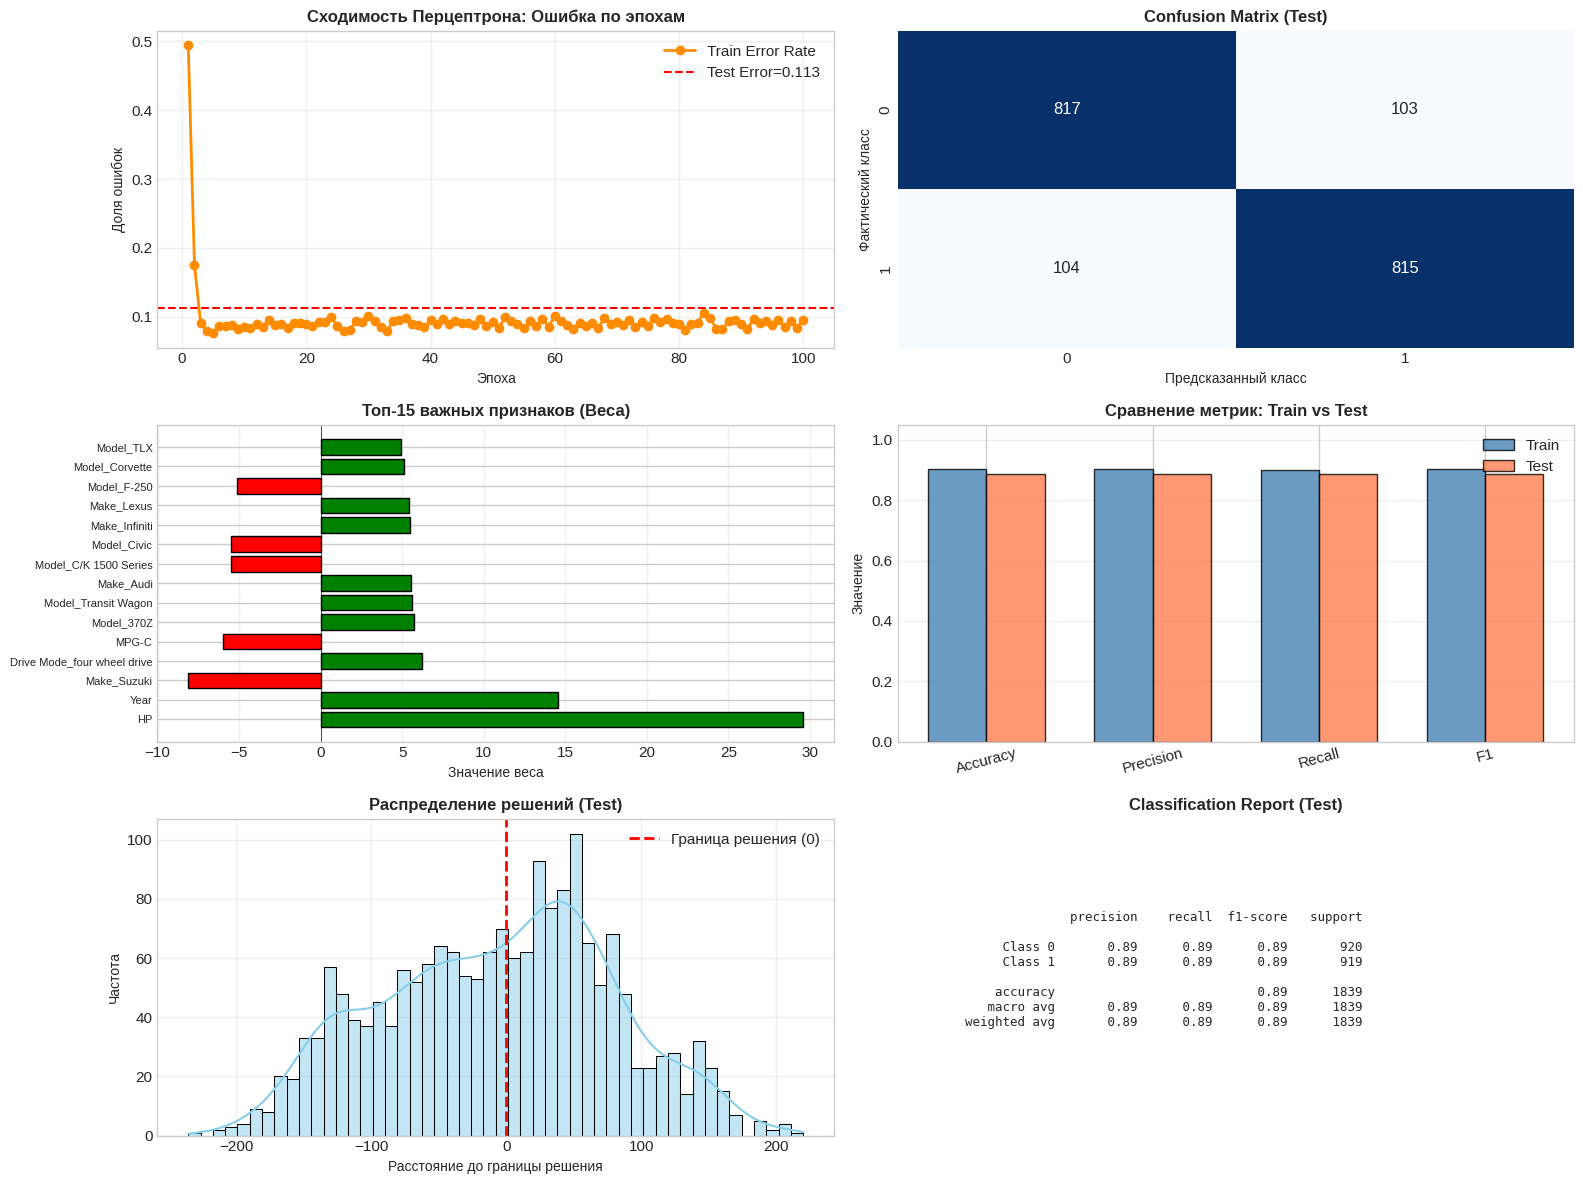


🔍 Диагностика Перцептрона:
  Количество эпох: 100
  Learning Rate: 0.01
  Final Train Error: 0.0956
  Test Accuracy: 0.8874

✅ Ошибка снизилась с 0.4942 до 0.0956

✅ Модель обобщает данные адекватно.

📈 Топ-10 признаков, УВЕЛИЧИВАЮЩИХ вероятность класса 1:
  + HP: 29.5952
  + Year: 14.5306
  + Drive Mode_four wheel drive: 6.2247
  + Model_370Z: 5.7541
  + Model_Transit Wagon: 5.6087
  + Make_Audi: 5.5281
  + Make_Infiniti: 5.4792
  + Make_Lexus: 5.4375
  + Model_Corvette: 5.1222
  + Model_TLX: 4.9605

📉 Топ-10 признаков, УМЕНЬШАЮЩИХ вероятность класса 1:
  - Make_Suzuki: -8.1173
  - MPG-C: -6.0088
  - Model_C/K 1500 Series: -5.5193
  - Model_Civic: -5.5185
  - Model_F-250: -5.1521


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. Класс Перцептрона (Реализация с нуля)
# ============================================

class Perceptron:
    """
    Простой перцептрон для бинарной классификации.
    Функция активации: Единичная ступенчатая (Unit Step)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _step_function(self, z):
        """Ступенчатая функция активации"""
        return np.where(z >= 0, 1, 0)

    def _compute_loss(self, y_true, y_pred):
        """Вычисление ошибки (количество неверных классификаций)"""
        return np.mean(y_true != y_pred)

    def fit(self, X, y):
        """Обучение перцептрона"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            # 1. Линейная комбинация
            linear_output = np.dot(X, self.weights) + self.bias

            # 2. Предсказание
            y_pred = self._step_function(linear_output)

            # 3. Вычисление ошибки для истории
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # 4. Обновление весов (Правило обучения перцептрона)
            # update = learning_rate * (y_true - y_pred) * X
            error = y - y_pred
            update = self.learning_rate * np.dot(X.T, error)

            self.weights += update
            self.bias += self.learning_rate * np.sum(error)

        return self

    def predict(self, X):
        """Предсказание класса"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self._step_function(linear_output)

    def score(self, X, y):
        """Точность модели"""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)

# ============================================
# 2. Подготовка данных
# ============================================

# Пример: 1 если цена выше медианы, 0 если ниже

# Создаем бинарную целевую переменную на основе Price
median_price = df['Price'].median()
y = (df['Price'] > median_price).astype(int)  # 1 или 0

X = df.drop(columns=['Price'])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# Масштабирование признаков (важно для сходимости)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 3. Обучение модели
# ============================================

# Параметры обучения
n_epochs = 100
learning_rate = 0.01

print("🚀 Запуск обучения Перцептрона...")
model = Perceptron(learning_rate=learning_rate, n_iterations=n_epochs, random_state=42)
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================
# 4. Оценка качества модели
# ============================================

def evaluate_classification(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}

# Оценка на обеих выборках
train_metrics = evaluate_classification(y_train, y_train_pred, "Train")
test_metrics = evaluate_classification(y_test, y_test_pred, "Test")

# ============================================
# 5. Визуализация результатов
# ============================================

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# --- 5.1 Loss History (Ошибка по эпохам) ---
ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, n_epochs + 1), model.loss_history, 'o-', color='darkorange', linewidth=2, label='Train Error Rate')
ax1.set_xlabel('Эпоха', fontsize=10)
ax1.set_ylabel('Доля ошибок', fontsize=10)
ax1.set_title('Сходимость Перцептрона: Ошибка по эпохам', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1 - test_metrics['Accuracy'], color='red', linestyle='--', lw=1.5, label=f'Test Error={1 - test_metrics["Accuracy"]:.3f}')
ax1.legend()

# --- 5.2 Confusion Matrix (Test) ---
ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['0', '1'])
ax2.set_yticklabels(['0', '1'])

# --- 5.3 Распределение весов модели ---
ax3 = plt.subplot(3, 2, 3)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.weights
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax3.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax3.set_xlabel('Значение веса', fontsize=10)
ax3.set_title('Топ-15 важных признаков (Веса)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.axvline(x=0, color='black', lw=0.5)
plt.setp(ax3.get_yticklabels(), fontsize=8)

# --- 5.4 Сравнение метрик Train/Test ---
ax4 = plt.subplot(3, 2, 4)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax4.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax4.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_names, rotation=15)
ax4.set_ylabel('Значение', fontsize=10)
ax4.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1.05)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# --- 5.5 Предсказанные вероятности (гистограмма) ---
ax5 = plt.subplot(3, 2, 5)
# Для перцептрона используем расстояние до гиперплоскости как аналог "уверенности"
linear_output_test = np.dot(X_test_scaled, model.weights) + model.bias
sns.histplot(linear_output_test, bins=50, kde=True, ax=ax5, color='skyblue', edgecolor='black')
ax5.axvline(x=0, color='red', linestyle='--', lw=2, label='Граница решения (0)')
ax5.set_xlabel('Расстояние до границы решения', fontsize=10)
ax5.set_ylabel('Частота', fontsize=10)
ax5.set_title('Распределение решений (Test)', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- 5.6 Классификационный отчет (текстовый) ---
ax6 = plt.subplot(3, 2, 6)
ax6.axis('off')
report = classification_report(y_test, y_test_pred, output_dict=True)
report_text = classification_report(y_test, y_test_pred, target_names=['Class 0', 'Class 1'])
ax6.text(0.1, 0.5, report_text, fontsize=9, family='monospace', verticalalignment='center')
ax6.set_title('Classification Report (Test)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('perceptron_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. Дополнительная диагностика
# ============================================

print(f"\n🔍 Диагностика Перцептрона:")
print(f"  Количество эпох: {n_epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Final Train Error: {model.loss_history[-1]:.4f}")
print(f"  Test Accuracy: {test_metrics['Accuracy']:.4f}")

# Проверка сходимости
if model.loss_history[-1] == 0:
    print("\n✅ Модель сошлась на обучающих данных (0 ошибок)!")
elif model.loss_history[-1] < model.loss_history[0]:
    print(f"\n✅ Ошибка снизилась с {model.loss_history[0]:.4f} до {model.loss_history[-1]:.4f}")
else:
    print("\n⚠️  Модель не сошлась. Попробуйте:")
    print("   - Увеличить количество эпох")
    print("   - Изменить learning_rate")
    print("   - Проверить линейную разделимость данных")

# Проверка на переобучение
acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
if acc_diff > 0.1:
    print("\n⚠️  Возможное переобучение! Разница Accuracy > 10%")
else:
    print("\n✅ Модель обобщает данные адекватно.")

# Топ-10 положительных и отрицательных весов
print(f"\n📈 Топ-10 признаков, УВЕЛИЧИВАЮЩИХ вероятность класса 1:")
top_positive = weights_df[weights_df['weight'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['weight']:.4f}")

print(f"\n📉 Топ-10 признаков, УМЕНЬШАЮЩИХ вероятность класса 1:")
top_negative = weights_df[weights_df['weight'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['weight']:.4f}")